In [1]:

import random

import matplotlib.pyplot as plt
from functools import partial
import networkx as nx

from gerrychain import MarkovChain
from gerrychain.constraints import (
    Validator,
    single_flip_contiguous,
    within_percent_of_ideal_population,
)
from gerrychain.proposals import propose_random_flip
from gerrychain.accept import always_accept
from gerrychain.updaters import Election, Tally, cut_edges
from gerrychain.partition import Partition
from gerrychain.proposals import recom
from gerrychain.metrics import mean_median, efficiency_gap
import numpy as np
from gerrychain import Graph

In [4]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)

gn = 6;     # grid size (k x gn, k x gn)
k = 5;      # number of districts
ns = 50;    # population per node
p = 0.5     # probability of being pink vs purple


graph = nx.grid_graph([k * gn, k * gn])

for n in graph.nodes():
    graph.nodes[n]["population"] = 50
    if 0 in n or k * gn - 1 in n:
        graph.nodes[n]["boundary_node"]  = True
        graph.nodes[n]["boundary_perim"] = 1
    else:
        graph.nodes[n]["boundary_node"] = False

cddict     = {x: int(x[0] / gn) for x in graph.nodes()}
total_pop  = sum(graph.nodes[v]["population"] for v in graph.nodes())
pop_target = total_pop / k
graph   = Graph.from_networkx(graph)

In [5]:
from gerrychain.tree import recursive_tree_part

ideal_pop = total_pop / k

# Generate the random assignment
random_assignment = recursive_tree_part(
    graph=graph,
    parts=range(k),
    pop_target=ideal_pop,
    pop_col='population',
    epsilon=0.1
)

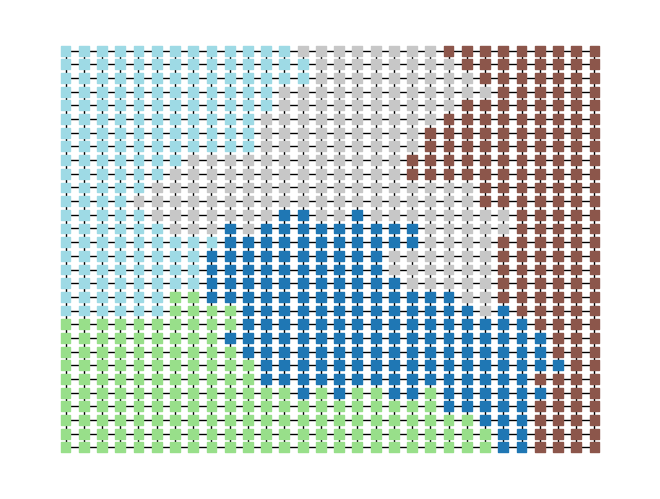

In [6]:
plt.figure()
nx.draw(
    graph,
    pos={x: x for x in graph.nodes()},
    node_color=[random_assignment[x] for x in graph.nodes()],
    node_size=ns,
    node_shape="s",
    cmap="tab20",
)
plt.show()

In [7]:
initial_partition = Partition(
    graph=graph,
    assignment=random_assignment,
    updaters={"cut_edges": cut_edges, "population": Tally("population"), "boundaries": Tally("boundary_node")},
)

In [8]:
district_boundaries = {}

# Iterate through all unique districts in the assignment
for d_id in set(initial_partition.assignment.values()):
    # Find nodes in this district that are part of any cut edge
    b_nodes = set()
    for u, v in initial_partition.cut_edges:
        if initial_partition.assignment[u] == d_id:
            b_nodes.add(u)
        elif initial_partition.assignment[v] == d_id:
            b_nodes.add(v)
    district_boundaries[d_id] = b_nodes

# Example: Print boundary nodes for district 0
print(f"Boundary nodes for District 0: {district_boundaries[0]}")

Boundary nodes for District 0: {(20, 5), (20, 11), (14, 16), (9, 8), (11, 5), (8, 12), (10, 9), (9, 11), (25, 1), (19, 15), (10, 15), (18, 4), (13, 17), (26, 8), (21, 3), (18, 16), (23, 9), (22, 10), (27, 6), (17, 5), (17, 14), (8, 11), (19, 11), (9, 16), (8, 14), (13, 4), (25, 0), (25, 3), (11, 16), (24, 1), (15, 4), (26, 4), (25, 9), (24, 10), (26, 7), (15, 16), (18, 12), (23, 2), (18, 15), (12, 5), (22, 3), (21, 11), (14, 5), (12, 17), (19, 4), (17, 16), (17, 13), (25, 2), (19, 16), (10, 7), (9, 15), (8, 13), (25, 5), (24, 0), (26, 6), (11, 6), (16, 5), (10, 10), (21, 4), (16, 17)}


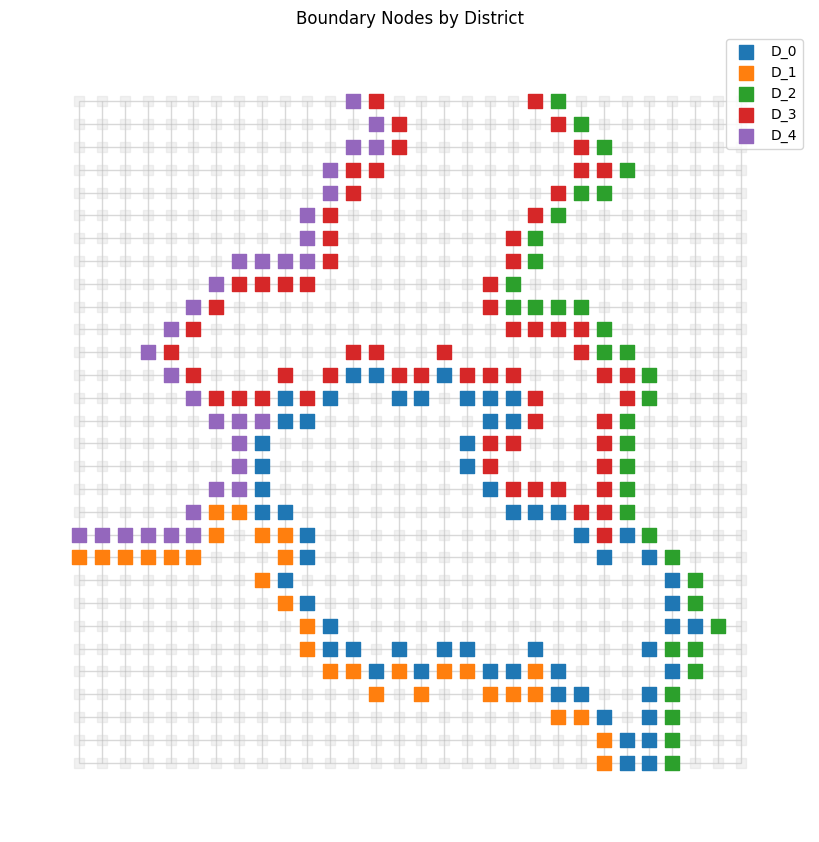

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# The position of the nodes is just the coordinate tuple itself
pos = {node: node for node in initial_partition.graph.nodes}

plt.figure(figsize=(8, 8))

# 1. Draw the underlying graph (edges and all nodes)
nx.draw(
    initial_partition.graph, 
    pos=pos, 
    node_color="lightgray", 
    node_size=ns, 
    node_shape="s",
    edge_color="gray", 
    alpha=0.3,
    with_labels=False
)

# 2. Overlay the boundary nodes for each district with specific colors
colors = plt.cm.tab10.colors  # Use a standard color cycle
for d_id, b_nodes in district_boundaries.items():
    nx.draw_networkx_nodes(
        initial_partition.graph,
        pos=pos,
        nodelist=list(b_nodes),
        node_color=[colors[d_id % len(colors)]],
        node_size=100,
        node_shape="s",
        label=f"D_{d_id}"
    )

plt.legend()
plt.title("Boundary Nodes by District")
plt.gca().set_aspect('equal') # Keep the grid square
plt.show()

In [10]:
for node in initial_partition.parts[0]:
    graph.nodes[node]['density'] = 0
for node in initial_partition.parts[1]:
    graph.nodes[node]['density'] = 100
for node in initial_partition.parts[2]:
    graph.nodes[node]['density'] = 200
for node in initial_partition.parts[3]:
    graph.nodes[node]['density'] = 300  